In [1]:
from sklearn import datasets

data = datasets.load_wine()


X = data.data  
y = data.target  


In [2]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [3]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the data to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA to reduce the data to 2 components
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Logistic Regression
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# Naive Bayes 
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)


In [10]:
# Evaluation metrics for Logistic Regression
print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg, average='macro'):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg, average='macro'):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_log_reg, average='macro'):.3f}")
print(f"R2: {r2_score(y_test, y_pred_log_reg):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, log_reg.predict_proba(X_test), multi_class='ovr'):.3f}")

# Evaluation metrics for Naive Bayes
print("\nNaive Bayes:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_nb, average='macro'):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_nb, average='macro'):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_nb, average='macro'):.3f}")
print(f"R2: {r2_score(y_test, y_pred_nb):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, nb.predict_proba(X_test), multi_class='ovr'):.3f}")


Logistic Regression:
Accuracy: 0.981
Precision: 0.978
Recall: 0.984
F1 Score: 0.980
R2: 0.969
ROC-AUC: 1.000

Naive Bayes:
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1 Score: 1.000
R2: 1.000
ROC-AUC: 1.000


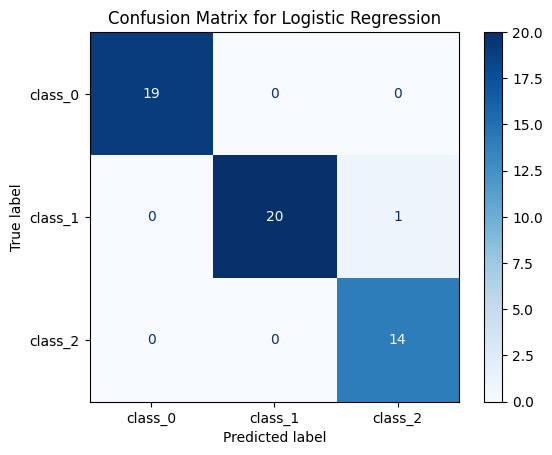

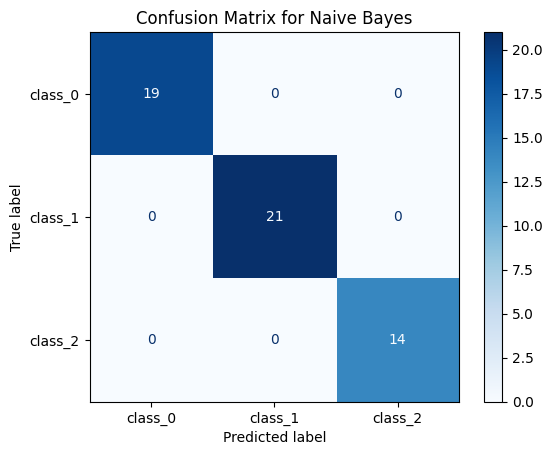

In [11]:
# Confusion matrix for Logistic Regression
y_pred_log_reg = log_reg.predict(X_test)
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=data.target_names)
disp_log_reg.plot(cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# Confusion matrix for Naive Bayes
y_pred_nb = nb.predict(X_test)
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=data.target_names)
disp_nb.plot(cmap='Blues')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()


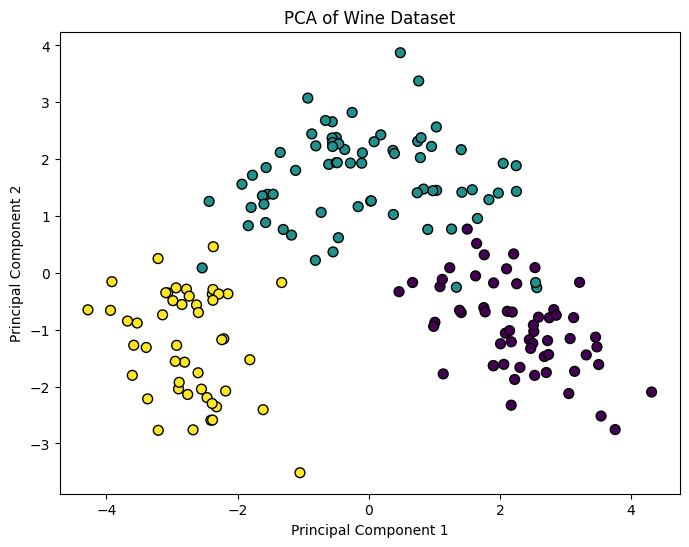

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


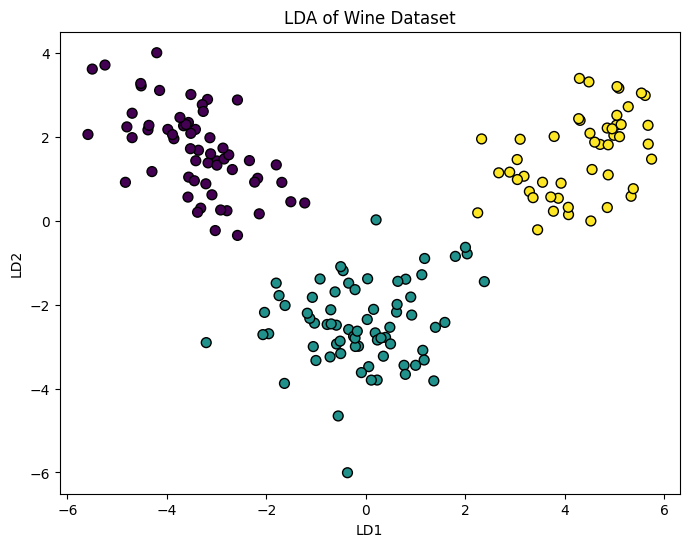

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('LDA of Wine Dataset')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.show()
